In [25]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import json
import re
import math

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sys.path.append('..')

from src.utility.config import DEVICE, QUANTIZATION_METHOD, QUANTIZATION_NUM_BITS
from src.layers import QuantizedLayers, replace_layers_with_quantizable
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.utility.quantizer import Quantization



# Set style
sns.set_theme(style="whitegrid")



In [26]:
def prepare_quantized_architecture(model):
    count = 0
    for name, module in model.named_modules():
        if hasattr(module, 'quantized_storage'):
            module.quantized_storage(
                num_bits=QUANTIZATION_NUM_BITS, 
                method=QUANTIZATION_METHOD
            )
            count += 1
            
    if count == 0:
        print("WARNUNG: Es wurden 0 Layer angepasst! Überprüfe src/model.py!")

In [27]:
def load_models(float_path, quant_path):
    print(f"Lade Float Modell: {float_path}")
    model_f = CNN(num_classes=150).to(DEVICE)
    
    model_f.load_state_dict(torch.load(float_path, map_location=DEVICE), strict=False)
    model_f.eval()

    print(f"Lade Quantized Modell: {quant_path}")
    model_q = CNN(num_classes=150).to(DEVICE)
    
    prepare_quantized_architecture(model_q)
    
    model_q.load_state_dict(torch.load(quant_path, map_location=DEVICE))
    model_q.eval()
    
    return model_f, model_q

In [28]:
def plot_layer_mse(df):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x='layer', y='mse', color='steelblue')
    
    plt.title("Quantization Noise per Layer (MSE)")
    plt.ylabel("Mean Squared Error")
    plt.yscale('log') 
    plt.xticks(rotation=45) 
    plt.show()

In [29]:
def visualize_comparison(model_f, model_q, test_loader, num_images=50):
    
    data_list, target_list = [], []
    for d, t in test_loader:
        data_list.append(d)
        target_list.append(t)
        if len(torch.cat(data_list)) >= num_images:
            break
            
    
    data = torch.cat(data_list)[:num_images].to(DEVICE)
    target = torch.cat(target_list)[:num_images].to(DEVICE)

    
    with torch.no_grad():
        out_f = model_f(data)
        out_q = model_q(data)
    pred_f = out_f.argmax(dim=1)
    pred_q = out_q.argmax(dim=1)

    
    cols = 8 
    rows = math.ceil(num_images / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
    axes_flat = axes.flatten() 

    if hasattr(test_loader.dataset, 'classes'):
        class_names = test_loader.dataset.classes
    elif hasattr(test_loader.dataset, 'dataset') and hasattr(test_loader.dataset.dataset, 'classes'):
        class_names = test_loader.dataset.dataset.classes
    else:
        # Fallback falls keine Klassen namen da sind
        class_names = [str(i) for i in range(1000)]

    print(f"Zeige {num_images} Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab")

    for i in range(num_images):
        ax = axes_flat[i]
       
        img = data[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5 
        img = np.clip(img, 0, 1) 

        ax.imshow(img)
        
        p_q_idx = pred_q[i].item()
        p_f_idx = pred_f[i].item()
        real_idx = target[i].item()
        
        name_q = class_names[p_q_idx]
        name_real = class_names[real_idx]

        is_correct = (p_q_idx == real_idx)
        has_changed = (p_q_idx != p_f_idx) 

        if has_changed:
            color = 'orange'
            
            title_text = f"Q: {name_q}\n(F: {class_names[p_f_idx]})"
        else:
            color = 'green' if is_correct else 'red'
            title_text = f"Pred: {name_q}\nReal: {name_real}"

        ax.set_title(title_text, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        
    for j in range(num_images, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [30]:
def assess_classification_performance(model, data_loader, device, model_name="Model"):
   
    model.eval() 
    
    all_targets = []
    all_predictions = []
    
    print(f"--- Starte Assessment für: {model_name} ---")
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_predictions)
    
    error_rate = 1.0 - acc
    
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    print("\n>>> Detailed Classification Report (Precision, Recall, F-Measure):")
    print(classification_report(all_targets, all_predictions, digits=4))
    
    TOP_N = 15 
    
    from collections import Counter
    class_counts = Counter(all_targets)
    
    top_classes = [cls for cls, count in class_counts.most_common(TOP_N)]
    
    mask = [t in top_classes and p in top_classes for t, p in zip(all_targets, all_predictions)]
    
    subset_targets = [t for t, m in zip(all_targets, mask) if m]
    subset_preds = [p for p, m in zip(all_predictions, mask) if m]
    
    if len(subset_targets) > 0:
        cm = confusion_matrix(subset_targets, subset_preds, labels=top_classes)

        plt.figure(figsize=(10, 8))
        try:
            import seaborn as sns
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=top_classes, yticklabels=top_classes)
        except ImportError:
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_classes)
            disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

        plt.title(f"Confusion Matrix (Top {TOP_N} Frequent Classes) - {model_name}")
        plt.xlabel('Predicted Class')
        plt.ylabel('True Class')
        plt.show()
    else:
        print("Zu wenige Datenpunkte für das Subset-Plotting.")

    return acc

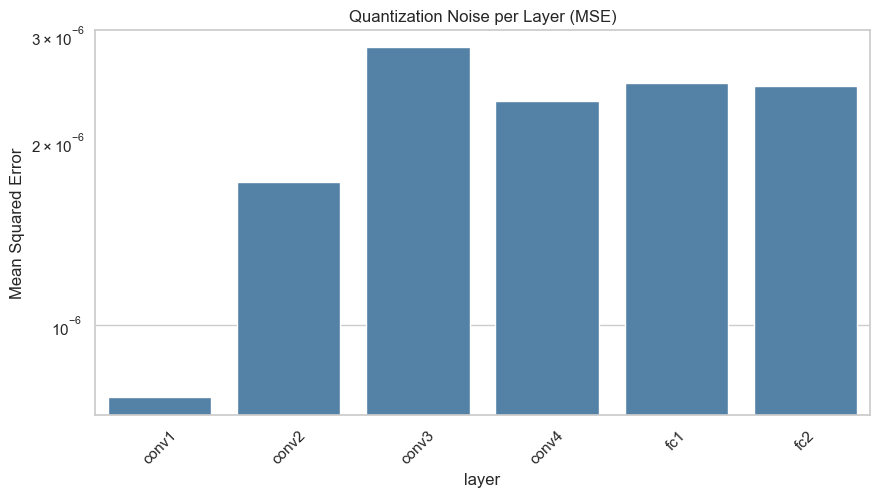

In [31]:
df_loss = pd.read_csv("../results/csv/weight_mse_2026-01-07_15-51-35.csv")

plot = plot_layer_mse(df_loss)

In [32]:
q_model = CNN(num_classes=150)
q_model = replace_layers_with_quantizable(q_model)

for name, module in q_model.named_modules():
    if hasattr(module, 'quantized_storage'):
        module.quantized_storage(num_bits=8, method='affine')

q_model.load_state_dict(torch.load("../results/quantized_models/cnn_mnist_quantized2026-01-10_13-04-45.pt"))

q_model.eval()

CNN(
  (conv1): QuantizedConv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): QuantizedConv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): QuantizedConv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): QuantizedConv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (fc1): QuantizedLinear(in_features=1024, out_features=1024, bias=True)
  (fc2): QuantizedLinear(in_features=1024, out_features=150, bias=True)
)

Lade Float Modell: ../results/models/cnn_mnist_2026-01-07_15-51-35.pt
Lade Quantized Modell: ../results/quantized_models/cnn_mnist_quantized2026-01-10_13-04-45.pt
Zeige 50 Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab


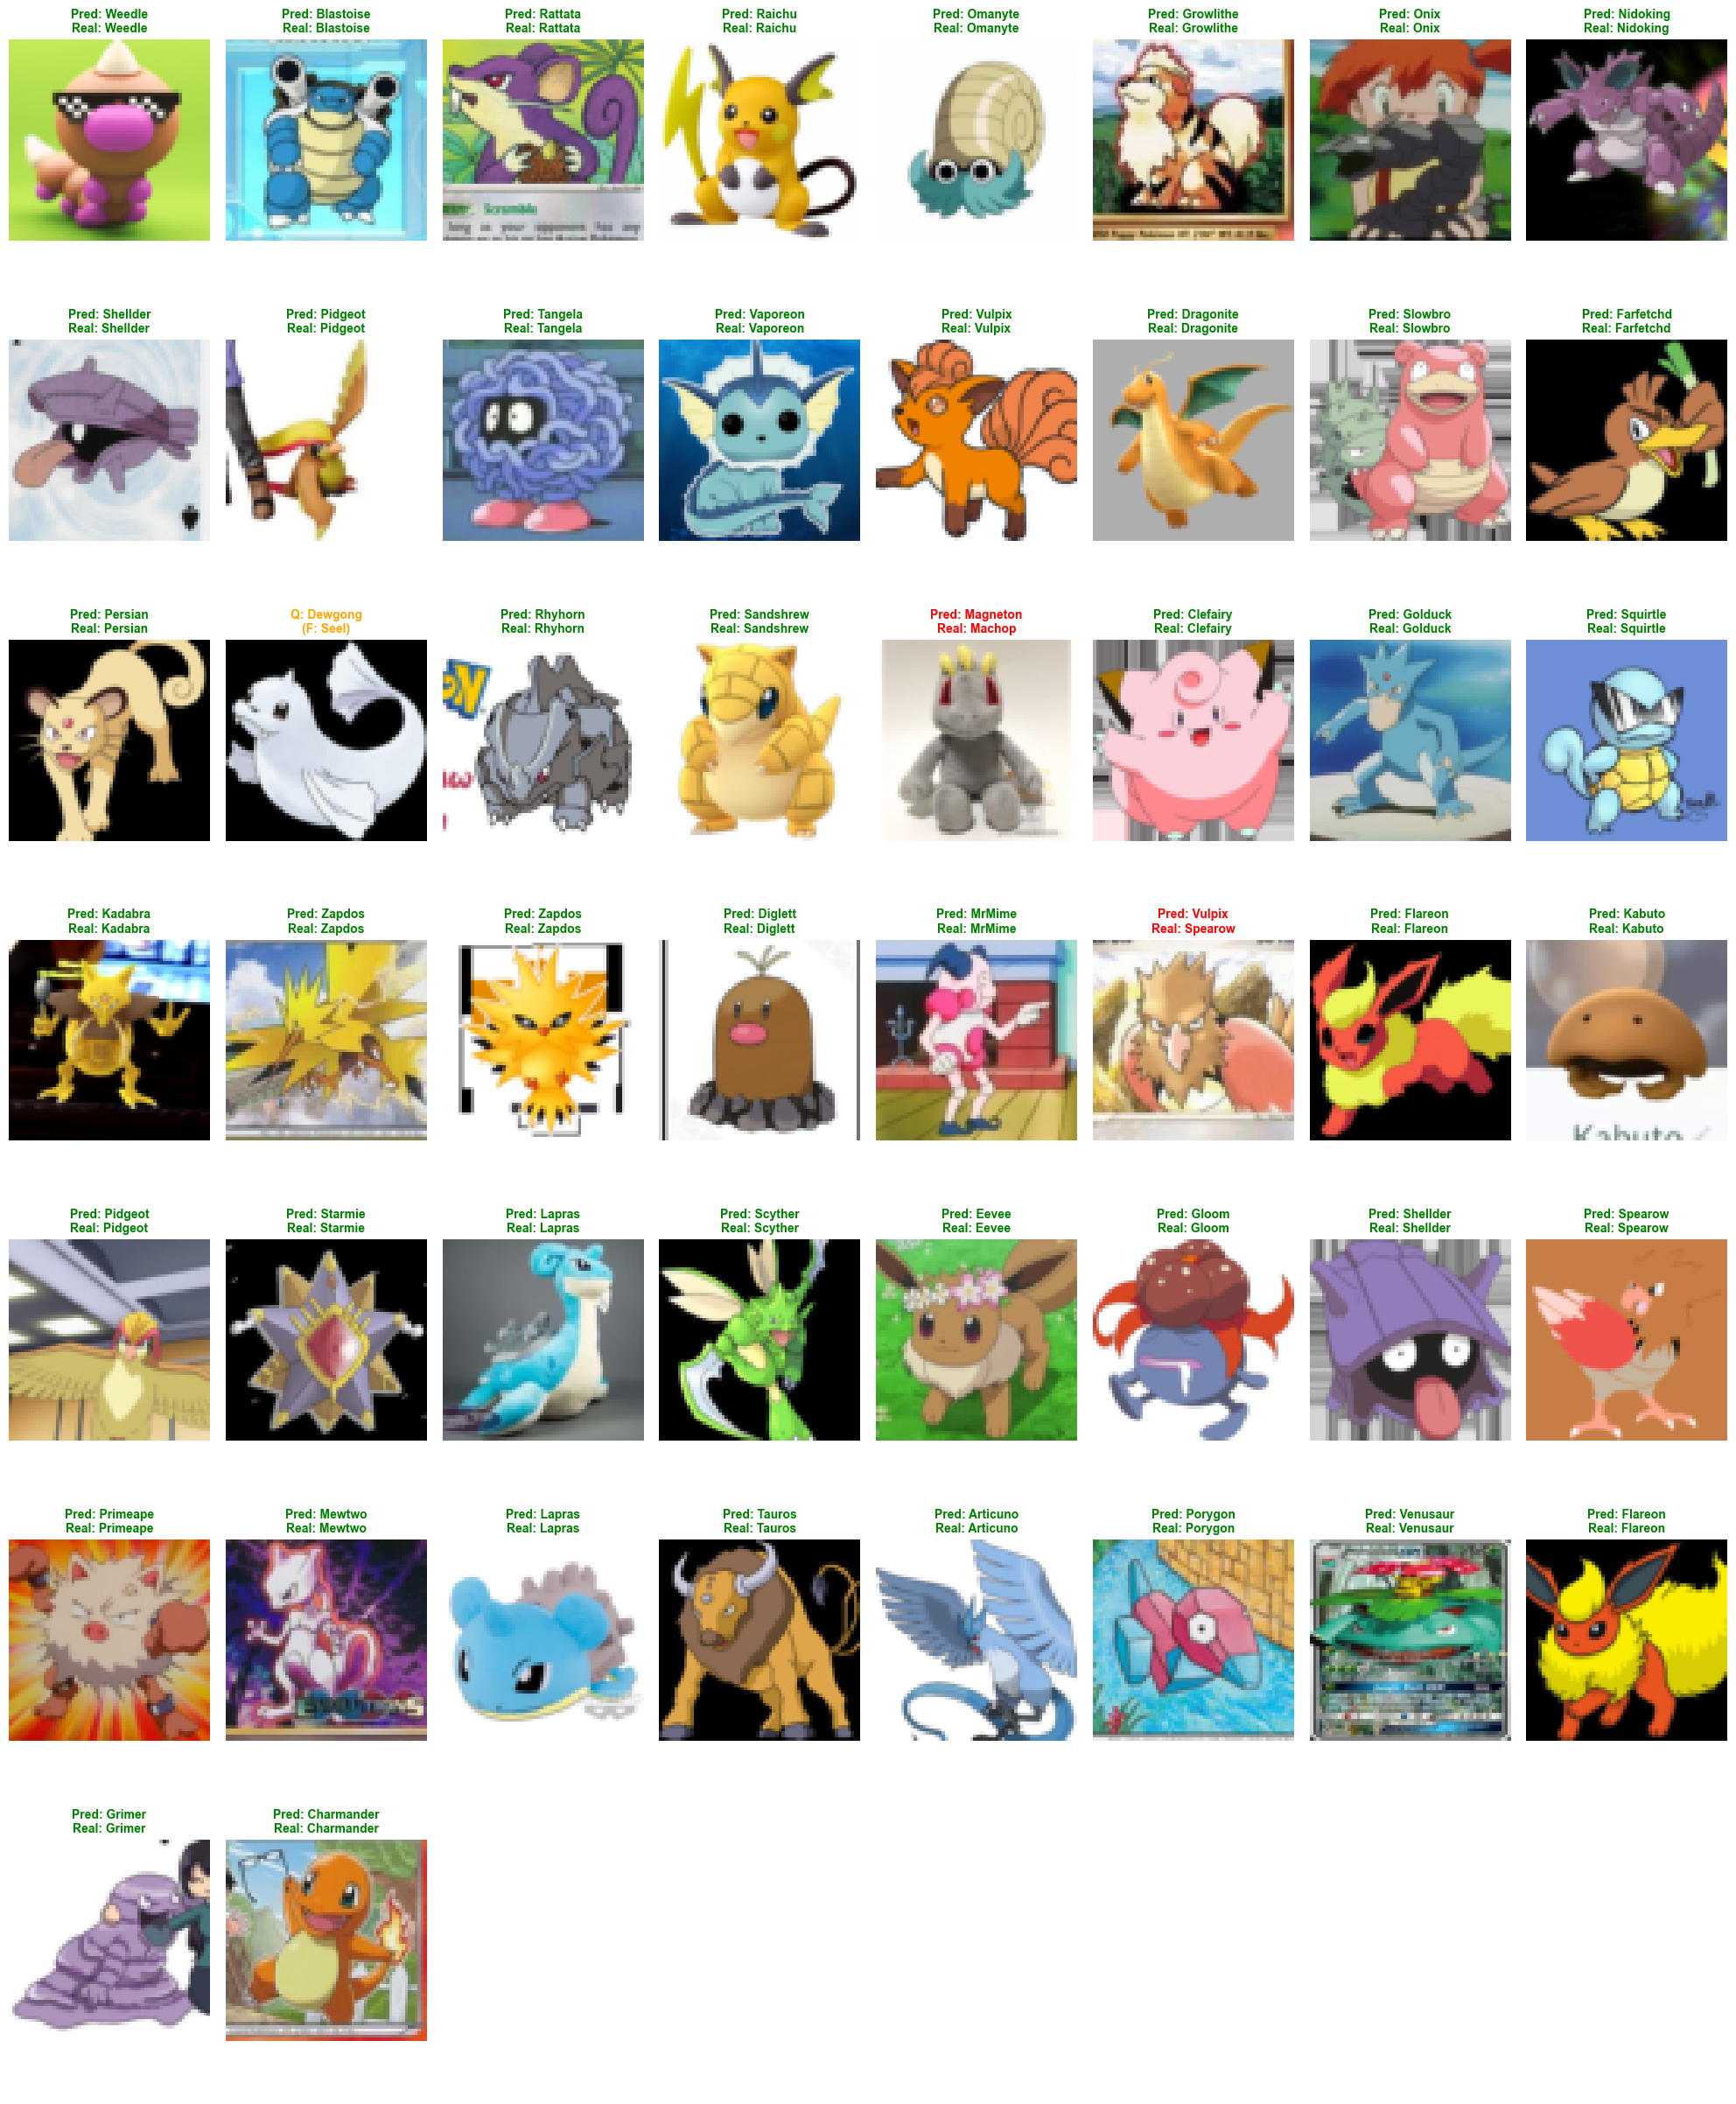

In [33]:
q_model_path = "../results/quantized_models/cnn_mnist_quantized2026-01-10_13-04-45.pt"
f_model_path = "../results/models/cnn_mnist_2026-01-07_15-51-35.pt"

f_model, q_model = load_models(float_path=f_model_path, quant_path=q_model_path)
train_loader, test_loader, *_ = get_data_loaders()

visualize_comparison(model_f=f_model, model_q=q_model, test_loader=test_loader, num_images=50)


In [34]:
weights_floats = f_model.conv1.weight.data.clone().cpu()

weights_dequant, _, _, _ = Quantization.quantize_tensor(weights_floats, num_bits=8, method='affine')

flat_float = weights_floats.view(-1).numpy()
flat_dequant = weights_dequant.view(-1).numpy()

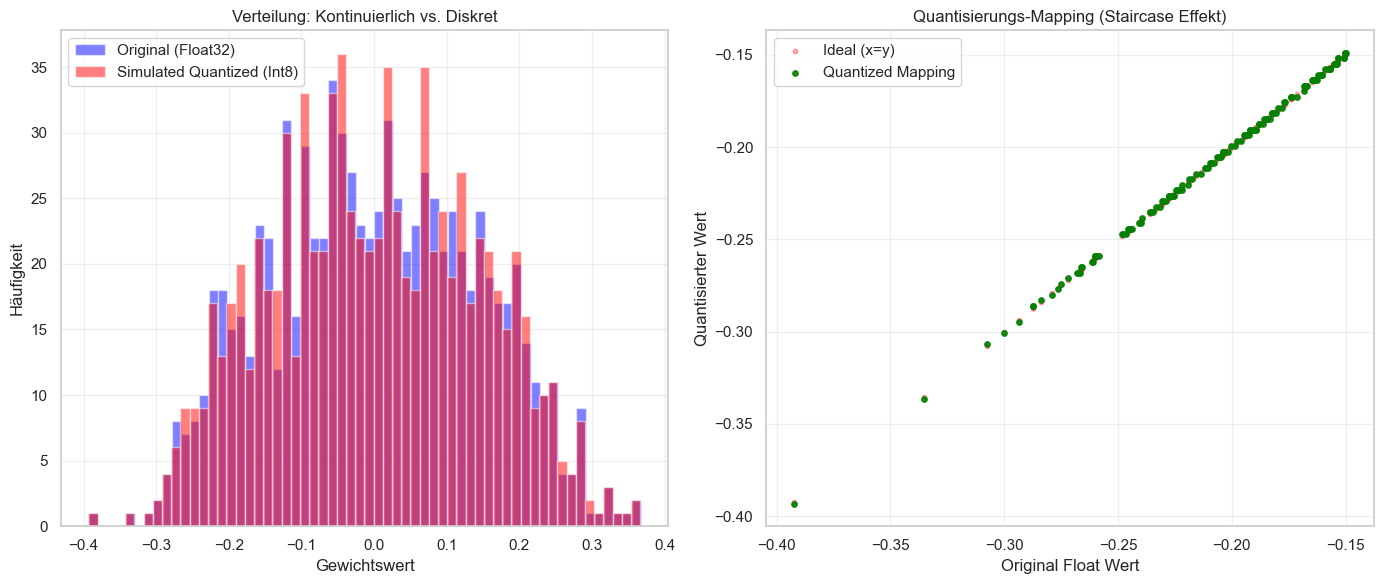

In [35]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.hist(flat_float, bins=60, color='blue', alpha=0.5, label="Original (Float32)")

plt.hist(flat_dequant, bins=60, color='red', alpha=0.5, label="Simulated Quantized (Int8)")

plt.title("Verteilung: Kontinuierlich vs. Diskret")
plt.xlabel("Gewichtswert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)


subset_idx = np.argsort(flat_float)[:150] 

plt.scatter(flat_float[subset_idx], flat_float[subset_idx], 
            color='red', alpha=0.3, label="Ideal (x=y)", s=10)
            
plt.scatter(flat_float[subset_idx], flat_dequant[subset_idx], 
            color='green', alpha=0.9, label="Quantized Mapping", s=15)

plt.title("Quantisierungs-Mapping (Staircase Effekt)")
plt.xlabel("Original Float Wert")
plt.ylabel("Quantisierter Wert")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- Starte Assessment für: Float Model (32-bit) ---
Accuracy:   0.9245 (92.45%)
Error Rate: 0.0755 (7.55%)

>>> Detailed Classification Report (Precision, Recall, F-Measure):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6667    0.8000    0.7273         5
           3     1.0000    1.0000    1.0000         9
           4     0.8333    1.0000    0.9091         5
           5     1.0000    0.7500    0.8571        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     1.0000    1.0000    1.0000         3
          10     1.0000    1.0000    1.0000         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13     0.9231    1.0000    0.9600        12
          14  

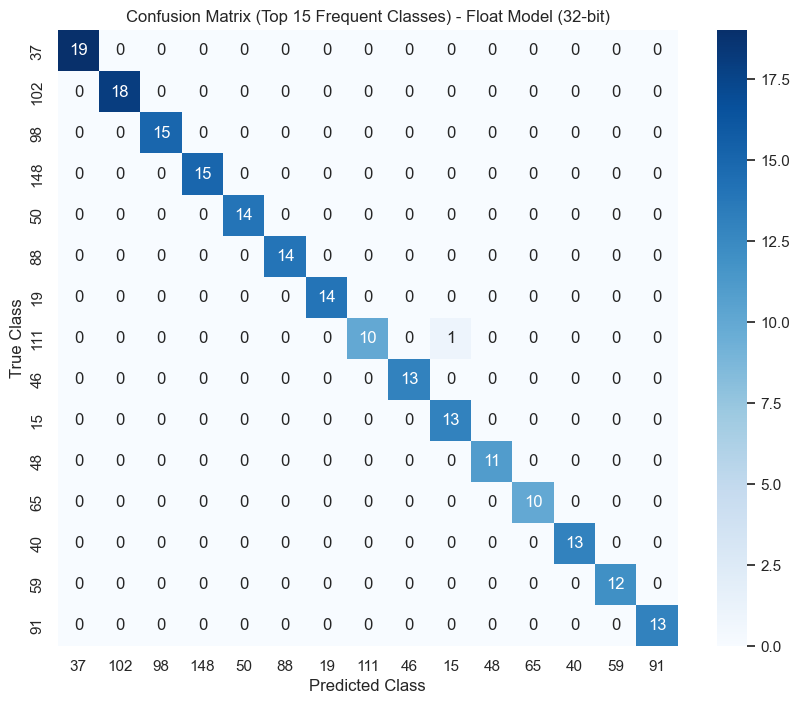

--- Starte Assessment für: Quantized Model (8-bit) ---
Accuracy:   0.9267 (92.67%)
Error Rate: 0.0733 (7.33%)

>>> Detailed Classification Report (Precision, Recall, F-Measure):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6667    0.8000    0.7273         5
           3     1.0000    1.0000    1.0000         9
           4     0.8333    1.0000    0.9091         5
           5     1.0000    0.7500    0.8571        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     1.0000    1.0000    1.0000         3
          10     1.0000    1.0000    1.0000         6
          11     1.0000    1.0000    1.0000         4
          12     0.5000    1.0000    0.6667         1
          13     0.9231    1.0000    0.9600        12
          1

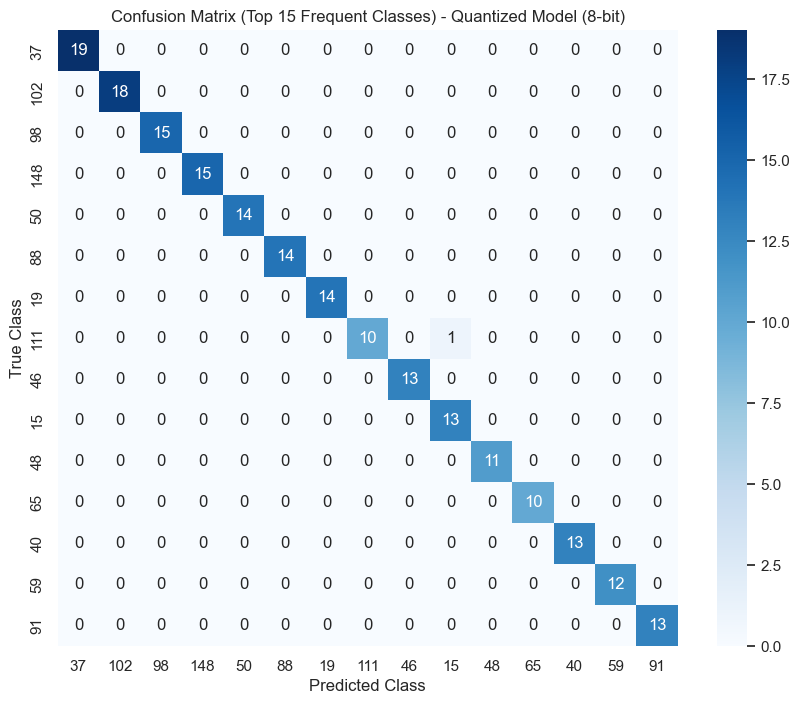

Das Modell hat -0.22% an Genauigkeit verloren.


In [36]:

acc_float = assess_classification_performance(f_model, test_loader, DEVICE, model_name="Float Model (32-bit)")
acc_quant = assess_classification_performance(q_model, test_loader, DEVICE, model_name="Quantized Model (8-bit)")

diff = acc_float - acc_quant
print(f"Das Modell hat {diff*100:.2f}% an Genauigkeit verloren.")